In [9]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import segmentation_models_pytorch as smp
from torchvision import transforms
from scipy import ndimage  # Essential for the shadow fix
import os
from glob import glob

import sys
import os

# Move up one directory to the project root
root_path = os.path.abspath(os.path.join('..'))
if root_path not in sys.path:
    sys.path.append(root_path)

# Now you can import your function
from src.get_satellite_image import get_aerial_image_tensor

print("✅ Successfully imported get_aerial_image_tensor")

# --- Environment Setup ---
device = 'mps' if torch.backends.mps.is_available() else ('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Running on: {device}")

# --- Load Your Refined Model ---
# We use the 'up-one-level' search we fixed earlier
try:
    model_path = glob("../models/final_refined_roof_model.pth", recursive=True)[0]
    print(f"✅ Found Model: {model_path}")
except IndexError:
    model_path = "models/final_refined_roof_model.pth" # Fallback to local folder

model = smp.Unet(encoder_name="resnet34", in_channels=3, classes=1).to(device)
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()

✅ Successfully imported get_aerial_image_tensor
Running on: mps
✅ Found Model: ../models/final_refined_roof_model.pth


Unet(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track

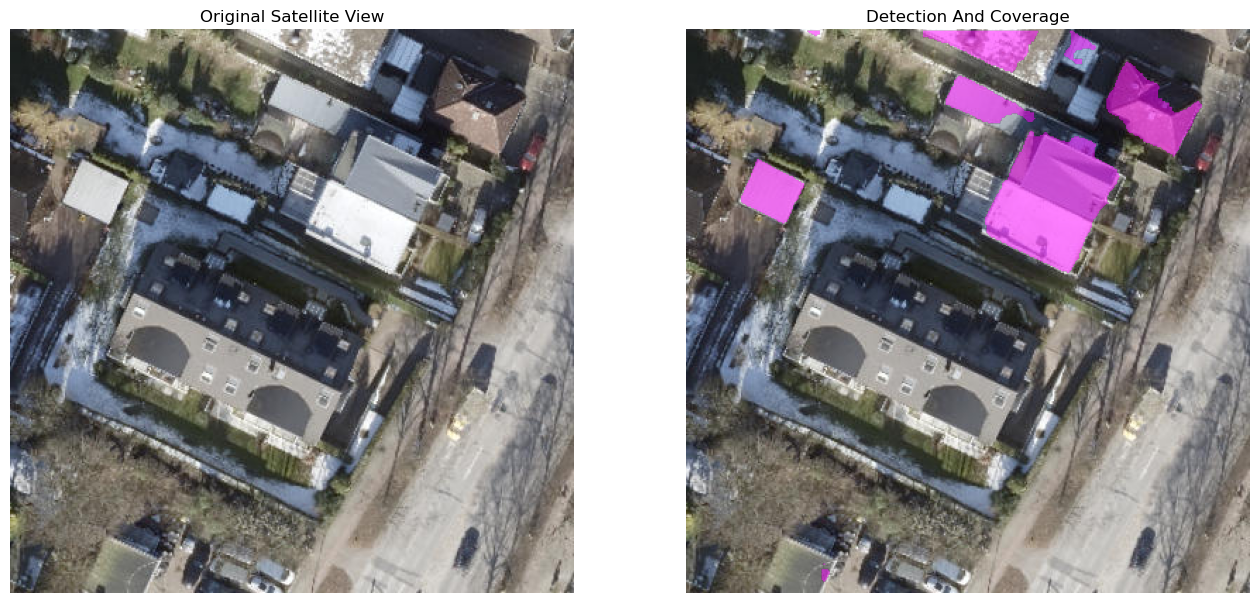

In [11]:
from torchvision import transforms

# 1. Download (returns 0-1 tensor)
img_tensor = get_aerial_image_tensor(lat=lat, lon=lon, zoom=19, size=400, device=device)

# 2. Add the Missing Normalization (for the Model's eyes only)
# This matches what your model learned during training
model_preprocess = transforms.Normalize(
    mean=[0.485, 0.456, 0.406], 
    std=[0.229, 0.224, 0.225]
)
# We apply it to a clone so we don't mess up the original for display
input_tensor = model_preprocess(img_tensor.squeeze(0)).unsqueeze(0)

# 3. Inference
model.eval()
with torch.no_grad():
    logits = model(input_tensor)
    mask = (torch.sigmoid(logits) > 0.5).float().squeeze().cpu().numpy()

# 4. Shadow Fix And Cleaning (using 'And')
mask_final = ndimage.binary_fill_holes(mask).astype(np.float32)
mask_final = ndimage.binary_closing(mask_final, structure=np.ones((3,3))).astype(np.float32)

# 5. Correct Visualization
# Since the function returns 0-1, we just convert back to HWC
display_img = img_tensor.squeeze().cpu().permute(1, 2, 0).numpy()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
ax1.imshow(display_img)
ax1.set_title("Original Satellite View")
ax1.axis('off')

ax2.imshow(display_img)
overlay = np.ma.masked_where(mask_final == 0, mask_final)
ax2.imshow(overlay, cmap='spring', alpha=0.5)
ax2.set_title("Detection And Coverage")
ax2.axis('off')

plt.show()